# Build a tiny GPT — a language model that actually writes

This is the capstone. Across four notebooks you built every piece of a modern language
model:

| notebook | idea you learned |
|----------|------------------|
| 1 · from scratch | a neuron, forward/backward, gradient descent |
| 2 · PyTorch | `loss.backward()` and the training loop |
| 3 · overfitting | train vs validation, generalization |
| 4 · embeddings & attention | words → vectors, and self-attention |

Now we assemble them into a working **character-level transformer** — a "nano-GPT" — and
**train it live** (about 15 seconds on a laptop) until it generates brand-new,
pronounceable words. Same architecture as ChatGPT and Claude, just tiny.

Three things a real LLM has that our attention demo skipped, and which we add here:

1. **Positional encoding** — attention is order-blind; we tell the model *where* each
   character sits.
2. **Causal masking** — to predict the next character, a position may only look at
   characters *before* it, never the future.
3. **Real training on next-character prediction** — the actual objective that makes an
   LLM an LLM.

Run top to bottom. Section 6 trains the model; Section 7 lets you generate with a
temperature slider.

## 1. Setup

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 100
ACCENT = "#2a9d8f"
torch.manual_seed(1337)
print("torch", torch.__version__)

torch 2.12.1


## 2. The data: just characters

An LLM predicts the next **token**; to keep everything readable, our tokens are single
**characters**. Our corpus is ~3000 English words (baked into this notebook, so nothing
to download). The model never sees word meanings — only sequences of letters and the
newline that separates words — yet it will learn the *shape* of English words: which
letters tend to follow which.

We build two little dictionaries, `stoi` (char → number) and `itos` (number → char), and
encode the whole corpus into one long tensor of integers.

In [2]:
WORDS = "abbacomes abeigh abord abort abrasive abrim absalom abutting acanthad accidency accite acerb acerbate acescent acetalize acetifier acetum achigan achorion aciliated ackey acockbill acor acorus acoumetry acousmata acrobatic acrook acrospire actioner activity actuation addie adducible adipocyte adsorbent advocator advowee aequi aerobious aeropathy affably affection afflicted afterglow agent agistor agoniadin agouta agrah agreeing agroan ailanthic ailantine aim aimee akindle akkad alabamian alabarch aladdin alaria alaunian albitite alepole aleuronic alfenide alids aliener alienize alimental alisp alkylize allagite allergic allogamy allurer almohade almswoman alochia alpha altercate alto altschin alveolate alvissmal amacratic ambay ambitty amblingly amidst amiles aminogen amissness amnesic amorosity amperage ampul amuyon analgic anan anandrous anangioid anaphoral androgone anepia aneuric angleworm angus anhinga anima annatto anneal annexa annite anniverse annoying annoyment anoetic anomalism anomural anorchia antacid antdom anthocyan antibalm anticker anticous antifelon antigod antipathy antisolar antler anywhen aotes apertly apexed aphelion apinae aplysia apneustic apobiotic apoblast apocopate apollyon apopyle apositic appall apparatus appertain appetize aquabib arabinic arachnid arales arar arbored archband archeion archsaint areca arena argiope argute arisen arkansas armload arose arriet arseniate arseno arsylene artcraft arthragra asbolin ascetical ascoma asha asherites ashir asquirm assiduous assize assuring astatic astraddle astrantia astrer asyndetic ataunt atavus atfalati athrob atlaslike atonement aumery aura australia auto autophony autosight avahi average avicolous avidious awardable axial axil axonolipa axostyle ayless azonal azotine azoxazole azure azurine baa babuism baccarat backflow baconist baconweed bacteric bahar bahnung bakairi balagan baldcrown balden ballooner balmacaan balsamine balsamy banchi bandusia banns bantamize banzai barathea barbacoa barbados bardy barfly barnyard baronage barong barosma bashkir basiate basilisk basos bastaard bathtub baudrons baxterian baybolt beadlike beadwork bearm beastlike bebloom beckiron becroak becross bedeguar bedoyo bedrowse beef beerage beevish befetter befool befrogged bego begone begonia begum behooving bejel beknight belaced belayer belialist believe bellonian belltail bellyman bemuddy bendingly benet benzoxate beothuk bepaste bepen bepester berakoth berbamine bere bergamiol beringite berley berthage berylate beseemly beshriek beshrivel besieged bespeak bessemer bestorm bethought betoss bewailer bezaleel bezique bhakta bhangi bhara bharal bier bifrontal bigamy biggish billfish bilo bimbil binoxide birding birdwise birdy biron bisbeeite bitterbur bixa blackface blank blanking blankit blankness blatjang blawort bleared bleater blennoid blink blister bloating blossomed blossomry blowze blueing bluntish blurrer blustery boarskin boatie bobbery bodge boding bodywood bolelike bolometer bomarea bombay booklover boomboat boone bordel bordured boschbok bosom bosporus boss botanist boterol botryllus bottoming bouget bounteous bowfin bowllike boxberry boxmaking bracker brambling brangle brawner brawnily breekums breezeway breton brewery brigatry briming brimmed brisque britoness bromyrite brooke brumstone brunonia bryonidin buccally budworm buffball buffle bugbane buginese bugology bulky bullary bultow bummler bungy burbark burfish burgensic burghbote burner burroweed burse busted busy butter buyides byssin cabotage cacao cadetship caeciliae caecotomy cafh cairn calfish calfskin caliburno callus calvous calycoid cameral camphire camused canicula cank cankery canoeist canopus cantata caperbush caperwort capewise caphar capocchia caprone caption carberry cardiform carful caribal carl carless carmalum carnalism carnify caroli carolina carotic carroty carryall cartsale casalty casebox casimiroa casuality catalpa catchfly catenae cationic caudices cauk cavascope caverned cebell cecrops ceiling celeste cephalata cercal cerillo cerise ceroxylon certitude certy ceruse cetane ceyx chalaze chalcone chalder chamber chamisal charlatan charpit chasseur chaya cheetie chelonin chemurgic chhatri chiasmal chignon chinkara chivalric chloroma choliamb chore choreoid chorizont chorus chrismary christ chumpaka chunk chylific cimbrian cimicoid cingulate circassic circlet circuity cirrolite cirrous cisco civilizer clancular clarain clarty classical clatsop claudian claustral clayware clearish cleck clee cliffy cliftonia clinic clinking cloisonne cloof clouded clough clovene clover clovery clownage clownheal coachway coadjust coalbin coast coaxingly cobbly coccerin cochlea cock cockaded cocozelle coffin colchyte coldish coldslaw collapse colliery colorful colugo columba comer commode commonize commorth compear comptonia conation conceity concupy condylome conformal confriar confront congoese conidial conjoint conopid conserve convict convictor convinced convolute cookishly cookshack copycat coquito cordite cordwood corema corinna corneitis cornulite corona corton cothurnal cothurnus cothy cotys coumalin couple covisitor crackling craglike craver crax creaght creamlike creoleize cresotate cresselle cribble cricetus cricotomy crig crile critique crocky croftland cromulent croppa crossbolt crosstree crotalism crotaphic crottels crowhop crowing crumble crushed cryostase crypt ctenocyst cuerda cuffin culverin cumulate cumulose cumyl curlew curlycue cursive cursus cute cyanotic cyclane cyclist cygnid cynical cyp cyrtopia cytomere daalder dacryops daffodil dagmar daisy daltonism damn dampness danalite dander danziger daresay dari darwinism dashedly datism daunt davach dealt deathward debase deborah debtful decachord decayless decried decussate dedicatee deducive deedily defecant defroster deifier deipotent deiseal delegable delineate demagogy demency demisuit democracy demolish demonial demurely demurrant demurring desmacyte detur deuced deviable deviation devitrify dewanee dhak diaereses dialect dialectal dialyze diapalma diaphony diapnoic diastase dibbler dicellate dicoccous didinium dido didynamy diffuse diglossia digynian dilling dimerous dimiss diploe dipsey diptera dipterad dirca dird directly direness dis disagreed disannex discord discovery disguised dishwater disrank distain distal disunite disvoice diswood dite divesture divinyl divorcive divulsor docetist dock doctorial dogma domatium doment donorship doob doorboy doraskean dosadh doss dossel doting doughboy doughnut dovyalis dowel dowery downflow draba drably drainless drawable drawbeam drew driveboat droner drouk drowse drug drumskin drunkenly dschubba ductor duculinae dukely dummered duny dupedom duplicand durax dusky dyer dyingness earlock eartab eave ebionitic ecchymose echiuroid ecru ectopia egg egghead eggler ektene elatha eleutheri eloigner elwood embalmer embolum embosture embroil emcee emeership emerize emetic emphysema enchanter enderon endoceras endocline endolemma endomixis engarment engaud engineman engrieve enigmatic enodally enquire enseam ensnarl enstatite enthetic entozoon enzyme enzymosis epicedial epidemy epihippus epilemma epimerite epimerum epimyth epipteric epistroma epivalve equerry ergmeter erika eristalis erotism eruditely escaper esconson escopette essayish essence essenwood essexite esteemer estimable estoile etchimin ettle euclea eumitosis eupeptic euspongia eutaxic eutectic eveline evenmete eversive exacting excedent exceeder exclave exemplar exility exodist exogamic exolemma exoplasm expansion exsurgent exudative eyedrop facemark fack faience fancywork fangless fanion faradism fardh farrandly fatefully fatima fatiscent faucre fauld faun feasten feckly fecula fedia feigning feltmaker felucca femicide fenceless fermila fetalism fetation fetticus feudalism fezziwig fiasco fiduciary filar filicin filly fingerlet finlike finnicize fiscalify fistnote fistulate fisty fitfully fitted fizgig flagging flagship flank flanky flatiron flaxseed fleckled fleetly flewit flex flightful flindosa flinkite flisky float flocculus floodcock flooding floorhead floppers floppy florican flourlike fluorspar fluoryl foaminess focally fogger folkvang fomenter fondler fontainea foochow foreclaw foredone forenamed foreshape forestial forestian foretime foreturn forewoman formamide forminate forwean fossed foughty fragrance frangi fremd frenchism frenchy frettage fretum frieda frieze fringelet friulian frivolize frolicly frustum fryer fuelizer fuirena fuji fullmouth fulvous funder furdel furzetop fusser gadroon gaily gainer gameful gamma gang gangue garage garapata gargety gargle garrafa garshuni gasmaker gasoliery gastral gausterer gauzily gawm gelidly gelignite geloscopy gelose genesee gentisic gestalt gewgawish gherkin ghostland gibingly giblets gigantic gilded gim gimp ginner ginnery girasole girlery girlfully girlishly girouette gitonin glaieul glaik glandlike glassweed gleety gliriform gloaming glochidia glosser glummy glutinose goatlike gobiidae goddard godlet goffered goggled gossipred gotra gourdful gowan grafship grafter gralline grant granter granulosa greed grendel gride grim grits grotesque grouf groupment grugru grumness grutch guarea guayabi gular gules gulravage gumless gumshoe gunk gymnasial gymnotid gymnura gynophore gyrfalcon haemogram hagrope hairmeal hairweed hallecret halmawise hamburger hamite hamperman handyblow hanging harderian harnesser harpyia hassock hatchel hatteria hausse haven haygrower hayz hazeled hazelwood hedebo hedger hedgewood heedful hekteus helenioid helion hellene hellenian hem hemipenis hemisect hemitone hemmel hemolytic hemometry henchman heparin hepatite hereamong hereto heretoga herma herne heroogony hespera hetaerist heterakid heteroepy hewhall hexapodal hibbertia hibernian hided higgaion highbred hillocked himation hinau hingeways hippolith hirse hispania hittology hive hogmanay hoin holiday hollaite hologamy homebred homeotype homerical homodont hon honeybee honora hook hookman hornish horologue horsehood horseweed hosteler hotch houghband housty hox hub hudibras huffle huge hughes humanhood humilific humism hunch huse hushful hyacinth hybridity hydrant hydromica hydrophis hydrozoan hylicism hymenoid hyostyly hypergon hypericin hypho hypnoid hypozoan ianthina ibsenic ibycter icaco iciness icosteine idlehood idolizer idoneity igniter iguanid ijo ileitis ilissus illish illogical illusion imaginant imbe imbecile immigrate imparity impeller imperator impervial impolite impostume imprecant impulse inbearing incisely incisory inclement inconnu incrust incutting induline indwell ineunt inexactly inexpress infantile inferrer infestant inflaming ingraft inhibit initive inket inkmaker inkstand innative inodes inodorous inolith inpatient inruption inspreith intercalm intercrop interlot intern interpage interpave interpour intimate intonable intruse invective invention invertor inweed iodize iodonium iodopsin iodyrite iotize iraqi isoetes isogram isometric isooleic isopodous issuer jackass jactant jainism jalapa janitor jaseyed jatrophic java jawbone jay jemmy jesuit jesuitize jewism jewless jharal jhuria jianyun jicaque jimmy jobbish judica juglans jump justly justness jutka kababish kajar kakke kalon kamarupa kanara karrusel kayaker kedar keerogue kelter kentia ker kerchoo ketonimin ketupa kex keylet khussak kikongo killcrop killdeer kilneye kilting kirker kirman kitalpha kleptic klipdas knagged knee knuckler kodaker kokoona konkani korero kozo krapina kritarchy kudize kurgan kurilian kurung kymation labroid laconizer lactol laicizer lake lakist laminary lanarkite lancelet lanciform landsturm langaha lango lanx lappa laputa laramide larnax larvalia lashlite lasting lateral latinate latten lattener lauia launch lavisher lawgiver lawk lawyery layback lazybones leadage leakance leaping leaves lecithal lee legacy legoa leimtype lemur lenslike lestrigon lettuce letty levelman levier lewdness libant libretti lichanos lichenin licker liferent lightish lignify liguorian limbic limean liming limit limma linoxyn lipogenic lisa listera lithogeny lithosis lithotype lithuria lituus litvak liyuan lobbyist locally lochage lochial locoism loculose locus logy loket lokiec londonian londony longspur lonk lookum loop loppy lored lorikeet lorraine losh lossenite lotment louisa lovably lowbred loyally lube lucubrate ludgatian luetic lumine lungie lupis lurk lustring luteinize luthern lutianid lyrebird lyrical lyriform machinely macilency maddening magianism magnetron maim main majolica makeshift makluk malbrouck maledict maleic malguzari maliki malinger malingery malva manerial mango manhead mannonic mantisia manzas marennin marion mariposan maronian marranism martian masonwork mastlike matagouri matfelon mating maturate maximal meat mecca medalist meddler medial mediatrix medino medius meethelp mehmandar melanite melanose meliaceae melinae meline melisma melodize mentalist menthol mentorial merocelic mesmeric mesodont mespilus messman mesvinian metallide methody micelle mickle micky miconcave micrander middle midge milcher milkiness miller millerism millioner milliphot mimical mingwort minikin miramolin mirfak misallege misbelief miserere misfare misgrave misleader mismade mitriform mix mobilian mobolatry mogdad moistener moko molality momotidae monadism moneyless mongcorn mongler mongst monilated monkeyfy monocarp monoline moodiness moondrop mordellid moresque mormyrus morntime morule moscow mot moulleen mountainy mouselet movably mudiria mudtrack mulligan multeity munge muraled murgavi murkish murph murrain musal musily muskish mutivity muttering myal myelocyst myitis myolysis myopathic myotome myotonia myoxidae mysell myzostoma naaman nagger naggy nagual nailing nailproof naipkin nais nakhoda nannander narcotine nascan nascency nassa natrix natt naucrar navvy naziritic neaped nebel neckline negativer negligee nemesic neoterism neritidae nervose nestle netting neuroma nevel nibs nicky nightwear niloscope nilous nippitate nipponium nitrator nitric nival noam nodular noisomely nomothete nonane nonmenial nonmotile nonself nonvital nonzonal nooklike nordcaper normalism nosine notarial notifier notifyee novella novem nucleator nucleoli numerate nunhood nurhag nutmeg nuttish nuzzle oafish oaritic obelism oblate obsolesce occupy oceanside ochreous octachord octarchy octodon oesophagi oestrus officious ogived oidium okra okthabah olacaceae oldster oleate olfacty olga olivetan olynthiac once ondagraph ondogram onlepy onslaught opalina openside operance ophidioid opinator opiniater optimal opulent oraculous oratory orby orchamus orgiastic orisphere orleanist ormolu ornithoid orontium ortheris orthian oryssus oscheal ostrya otherism otiosity oukia out outbawl outbleed outbond outcourt outcut outfit outgain outhouse outrance outreign outsally outshake outsift outsmart outstare outstink outswing outtaken outwards outyelp overalled overboard overbold overbrace overdoze overhorse overidly overmask overmotor overready overrude oversnow overteem overthick overturn overwet oxaluria oxyrhynch packhouse padfoot padlock paeanize paganism page pajama pale palestra panagia pandy panning panoply panzootic papalize papistry parabulic parader parameric paramylum parasceve parlous paroch paroecism parrhesia parriable parry parsonese parthian partible parvenu pastness patchy patelloid patrizate patronage patter patterner pausation payable payee payer payong pea peaceable pearling pearlwort peatman peccant pedated pedetinae peerling pega pegasidae pegbox pegger pegman pelopidae penchute penthorum penthrit pentine peplus percidae perdicine perfusive pernettia perosis peterkin petrosa pewfellow peyotl phalangid phallism phasma phiale phimotic pholcoid phon phrynin phthalide phugoid phyllomic picrotin picryl pictorial picturer pielum pimplinae pinery pinguin piniform pinker pinkroot pioneer pipeless pipped pise pisky pitapat pithiness placoidei plainful planarida plantad plateaux plateless platyopia pleasable plenitude plentiful pleroma plethora plica plication plotless plounce plume plunther pluripara poachable pockhouse pockweed podgily poethood poictesme poiser poisonful pokable pokeberry poking politic polladz polo poltinnik polydermy polygyral polypi polytypy polyzoal pomaceae pope poplar portless portulaca portunus porulous possum potdar potlatch potpie pouch pouchlike pouf pouncing poundmeal pourer powerboat praecipe pratap prawn preadhere preadmit preallude preaxial prebasal precaval preceding precursal precut predate predicant prefright preinvest prelithic preloral preneural prepave presenced prettily prickling priding primatal primine primitiae prior priorship proem profound progeny promythic propionic proschool prosodiac protagon prote prowess prunase ptarmica pteroma puddled pudency pudent puffin pumpman punic punitive pupiform pupivore puppet puppylike purist purseful purslane puseyism puttyroot pyelotomy pylagore pyridone pyroscopy quaequae quartzite quattie quayman queachy queery quemado quench querken quern query quetch quick quickset quieting quietus quillaic quinary quondam quote rabanna rabbanist race raceabout rachitome radio ragstone raisiny ramada ramate ramet ramie rammack ramneek ramnes ramosity ramule randall randing raphidiid raptatory rasant rascalry raser ratcher ratement ratio rattlebag rattlenut ravensara ravenwise razee reak rearmost reaver rebid rebrace rebreathe rebundle rebut recash recency recharter rechuck reckoning reclusive recoat recoiner reconcile reconvict reconvoke recordist rectopexy redaub redesire redleg redstreak reedlike reedmaker refectory refusable refuter regaler regather reglet regratify regulate regulator rehazard reimprint reinfest relabel relatch relaxedly reliction reliquian reload remijia remolade renewably reobtain repackage repaper repermit replevy repressed repriever repulsive requisite reremouse resalt reseam resiccate resoil resonance resorb respire restable restack resumer rethrive retier retiform retinize retooth retrip retry revelment revibrate rewarn rewhelp rhomboid rhubarby rhythmal rhytidome ribroast ricinine rid rigor rimfire rioting rippier risk rivalrous roadcraft roborant roborate robotism robotry rockling rodknight rollicker romagnese romanza rome romerillo rontgen rooklike roomy rootlike roselite rostel rostrate rotatory rouman rowan rowty royet rubbishly rubidine rubific rufescent rugosity runaround runrig ruskinian ruthless rype sabalo sabelli sacatra sadh safawid safranine sailplane salivan salol salpinges salve salvia samsam samurai sandless sandust santolina sapota saprocoll sart satellite sattva saumur scaffie scalopus scanian scaphite scapple scarface scarn schistic sciuridae sclera scoinson scorify scotching scrabble scraper scrapping screendom screeved scriggler scroll scroo scrounger scruffman scuddick scudo scurvish seabeach seasick secluse secondly seedling seerfish seiyukai seizure semibase semihot seminase seminegro semite senaite senatress sensism sensum serbian serdar serenity serjeant sesterce sestet settledly sextant sfoot shad shader shafiite shaigia shathmont shavee shawlless shean sheffield shibar shilpit shipment shippable shirring shitepoke shoalwise shorebush shortia shotweld shou showroom shrubland shutdown sickling sicyos sida siddhi signless simian simoleon simonist sinewless singfo singkamas sinkfield sinusal siphon siping siscowet sissy sist sitzmark sizarship skair skep skiametry skibby skijore skillet skimpy sklate slacking slagman slangily slatify slatter slavering slaw slidehead slighted slipcoat sloom smectite smicket smiter smoker smoothify smote smur snaillike snead snift snipelike snippy snoring snorker snorty snubproof snuffish soapbark soce sod soil solarium solipedal soloth solubly sooky sophia sophian sophy sorcery sororal sourish sozin spae spagnuoli sparus spass spathous speakies specifier speckless speeder sphenisci sphenoid sphery spidery spiritism spiritous spiro spirula spondylid sportful sprayless spyboat squatmore squeezer squencher squib stagnum stairless stamineal stanchly stankie stanzaic starful starlet starty starworm stature stavewise stentor sternage sticker stickleaf sticklike stigmaria stokavian stokesia stomach stomatal stonehead stoneyard storken storm stoup straggly straked strath strelitzi stretto strid stridling strigilis striper stripped strone strophoid strowd strumae stuck studdle studfish studiable stuff stumpish stumpwise stung stylelike stylolite styrene styrylic suavify subatomic subcasino subduing suberane sublessee sublimed sublunar submiss subneural suboptic substant subversal subvicar succub suckle suff suimate sultam summerer sungha supellex surfy surliness surveyor suspicion sussexite susurrus swagsman swanweed swarbie swartish swathable swazi swinging swipe swith swoosh sybaritic sybotic sylvan synagogue synalgia syntheses syntropy syphilize syphiloma syrtic systylous tabacum tabber tabulable tacanan tacca tachylite tadousac tahami tailender taimen tain taintor talabon talari talepyet tallet talloel tamara tammanial tamper tamul tandemize tangent tankmaker tankroom tannery tantrist tapetum tardiness tarentala tarentola tariric taroc tarsale tarse tartarous tatarian taught tautness tawdered tayer teacake teaching teaming teatime technics techous tectonic teeming teewhaap telegu tention tercelet terpene terrane tertial tesack tesuque tetanoid tetrao tetrazine teucrin thalassal thegnlike thema theodosia theohuman theonomy thesicle thestreen thialdine thienone thine thinkable thiolic thoric thorite thoron thoughted thowt throating throngful thurifer thymene thyreosis tickney tideswell tidley tidyism timbreled tingle tinned tinsman tintie tip tirer titanium titbit titterel tlascalan toadflax toadling tocokinin tomato tomnoup tonicize toothache topepo topically toplofty tora torbanite tore torero toreutic torus totterer touchless toweling townhood townlet towrope trabeated tradeful tragi trama tramline trank trapmaker trauma traverse travertin tredecile treebeard treeman tremie triacid triazoic tridymite trigone trihydric trinity tripudium tritonal triumph triweekly tropical trousered troutbird tst tsumebite tubeman tubulose tumulose tunner tunu tupuna turbith turd turgency turgent turklike turnback turncap turtan tweezers twibilled twiddly twigger twiscar typhic ubiquity ugrian ulcuscle ulmous ulnar uloncus umbeled umu unaged unaimed unapropos unblotted unboxed unbroken unbrooch unburning uncapable unchafed uncharity unclamped unclawed unclinch unclipper uncostly uncurse undamaged undaub undefeat undelated underarm underclad underhive underpen undersort undodged undressed undunged unerected unexalted uneyeable unfanned unfirmly unfix unflaky unflanged unflushed unforfeit ungarnish ungroined unguicorn unguided unharped unhauled unhealed unheed unhefted unhomely unhoned unhosed unhostile unhull unhurdled unignored unimagine unitarian unjailed unkill unkinlike unknave unlanguid unlarge unleal unlearnt unlent unlie unlikely unlimber unlive unmackly unmalted unmannish unmelting unmiter unmoaned unmundane unneedful unnestle unobscene unown unpaired unpieced unplashed unplayed unpointed unprying unpuffed unquashed unquelled unrelated unrifted unrivaled unroved unrow unsafely unsavable unschool unserried unsevere unshaded unshrew unsliced unsmelted unsnare unsought unsteep unsteeped unsting unstretch unswell untinned untombed untopping untough unvelvety unvenom unvisited unwall unwax unwayward unwilily unwire unwoeful unwrench upbind upblacken upbreed upbrim upcreep upcurl upflash upgully upgush upharbor uppop uprisal upstairs upstreet urceolar urocanic uselessly uskara usucapion usurer usuress usurper uttermost uvic vachellia vaguity vailable vaivode valencian valeta valiship valvelet vampyrum vanadiate vanadium vandalic vangee varicella variety vaselike vealy vei veininess velar vellosine velveted venator venesia venomness verbosity verdin versicle versual vetch vexed vibex vibrate vibrissa vile vilicate villate vinage viperess virilify vistlik vitaglass vitelline vives vocalist volstead volunteer voluta vorticose vote vowelism voyage vulsellum wabby waco waddent wadmal waggishly wagling waicurian waise walletful wampee ward wardapet wardmaid warmth warnt washboard wastable wastage waveson waxily waxworker wayao waygang wayless waymaker waypost weaken weanyer weariable weasel weaved weldable welk welling wheatworm whenever whereso whift whish whiteness whooplike whorly whyo wideness wiener wierangle wifely wilson winch windbore windring wingle winnonish wintry witchet witchleaf withdraw withheld withypot wode wolfen wolfram woodhole woodpile woodrow worcester wordless workbox wormholed worthship woundwort woy wrentail wrongly wrytail xenogenic xeres xylophone xylylene yabble yachting yarkand yawny yester yeuk yook yttric yucateco yurak yutu yuzluk zaffer zealless zendik zeoidei zermahbub zest zeuglodon zizz zobo zoeal zoic zonary zootrophy zygotoid zyryan".split()

rng = np.random.default_rng(0)
rng.shuffle(WORDS)                       # shuffle so training sees all letters early
text = "\n".join(WORDS) + "\n"
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

def encode(s): return [stoi[c] for c in s]
def decode(t): return "".join(itos[int(i)] for i in t)

data = torch.tensor(encode(text), dtype=torch.long)
print(f"{len(WORDS)} words, {len(text)} characters")
print(f"vocabulary ({vocab_size} symbols): {''.join(chars).replace(chr(10), '\\n')}")
print("first few words:", WORDS[:6])

3000 words, 24943 characters
vocabulary (27 symbols): \nabcdefghijklmnopqrstuvwxyz
first few words: ['leimtype', 'tonicize', 'coaxingly', 'agistor', 'valiship', 'zealless']


### The task, concretely: predict the next character

We slide a small window (`block_size` characters) over the text. The model sees the
window and must predict the **next** character at every position. Here are a few
(context → next) pairs the model learns from:

In [3]:
block_size = 16   # how many characters of context the model sees at once

sample = data[:block_size + 1]
for t in range(1, 6):
    ctx = decode(sample[:t]).replace("\n", "\\n")
    nxt = decode([sample[t]]).replace("\n", "\\n")
    print(f"  after '{ctx}'  ->  predict '{nxt}'")

  after 'l'  ->  predict 'e'
  after 'le'  ->  predict 'i'
  after 'lei'  ->  predict 'm'
  after 'leim'  ->  predict 't'
  after 'leimt'  ->  predict 'y'


## 3. Two new ingredients

**Positional encoding.** In notebook 4, attention treated a sentence as an unordered bag —
it had no idea "cat" came before "sat". But order is everything in language. The fix is
simple: alongside each character's **token embedding** (what it is), we add a **position
embedding** (where it sits). Both are learned vectors; we just sum them.

**Causal mask.** We're training the model to predict the *next* character. If it were
allowed to look *ahead*, the answer would be sitting right there — no learning needed. So
each position may only attend to itself and positions *before* it. That's a
lower-triangular mask: we set the attention scores to future positions to −∞ before the
softmax, so they get zero weight.

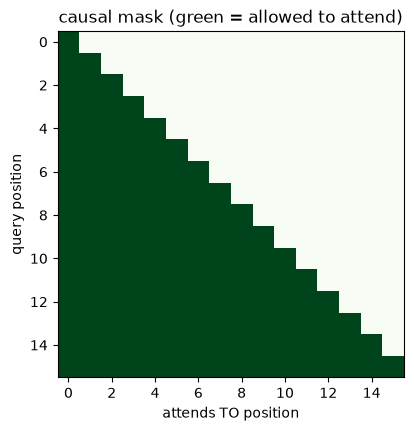

Row i is allowed to look only at columns 0..i — never at the future.


In [4]:
mask = torch.tril(torch.ones(block_size, block_size))
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.imshow(mask, cmap="Greens")
ax.set_title("causal mask (green = allowed to attend)")
ax.set_xlabel("attends TO position"); ax.set_ylabel("query position")
plt.show()
print("Row i is allowed to look only at columns 0..i — never at the future.")

## 4. The model — one transformer block

Here is the whole thing. Read it against what you already know:

- `token_emb` / `pos_emb` — the two embeddings from Section 3 (embeddings = notebook 4).
- `Head` — **exactly** the self-attention from notebook 4 (`softmax(QKᵀ/√d) · V`), now with
  the causal mask applied. Several heads run in parallel (multi-head attention).
- `mlp` — a small 2-layer network applied at each position (a neuron stack, like notebook 1).
- Residual connections (`x = x + ...`) and `LayerNorm` — the standard glue that keeps deep
  nets trainable.
- `lm_head` — projects each position to a score for every possible next character.

When we pass in `targets`, it also returns the **cross-entropy loss** — the multi-class
cousin of the binary loss from notebooks 1–3.

In [5]:
n_embd = 48
n_head = 3

class Head(nn.Module):
    # one self-attention head with a causal mask
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.head_size = head_size

    def forward(self, x, return_att=False):
        B, T, C = x.shape
        k, q, v = self.key(x), self.query(x), self.value(x)
        att = (q @ k.transpose(-2, -1)) * self.head_size ** -0.5   # QKᵀ / √d
        att = att.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # causal mask
        att = F.softmax(att, dim=-1)                               # weights sum to 1
        out = att @ v                                              # blend the values
        return (out, att) if return_att else out

class TinyGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb   = nn.Embedding(block_size, n_embd)
        self.heads = nn.ModuleList([Head(n_embd // n_head) for _ in range(n_head)])
        self.proj  = nn.Linear(n_embd, n_embd)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
                                 nn.Linear(4 * n_embd, n_embd))
        self.ln = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.token_emb(idx) + self.pos_emb(torch.arange(T))    # what + where
        x = x + self.proj(torch.cat([h(x) for h in self.heads], dim=-1))  # attention (+residual)
        x = x + self.mlp(x)                                        # per-position net (+residual)
        logits = self.lm_head(self.ln(x))                          # score every next char
        if targets is None:
            return logits
        loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

model = TinyGPT()
print(model)
print(f"\ntotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TinyGPT(
  (token_emb): Embedding(27, 48)
  (pos_emb): Embedding(16, 48)
  (heads): ModuleList(
    (0-2): 3 x Head(
      (key): Linear(in_features=48, out_features=16, bias=False)
      (query): Linear(in_features=48, out_features=16, bias=False)
      (value): Linear(in_features=48, out_features=16, bias=False)
    )
  )
  (proj): Linear(in_features=48, out_features=48, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=48, out_features=192, bias=True)
    (1): ReLU()
    (2): Linear(in_features=192, out_features=48, bias=True)
  )
  (ln): LayerNorm((48,), eps=1e-05, elementwise_affine=True, bias=True)
  (lm_head): Linear(in_features=48, out_features=27, bias=True)
)

total parameters: 31,419


## 5. The generate function

To write text, we feed the model a starting context (just a newline), let it predict the
next character, **sample** one from the probability distribution, append it, and repeat.
The **temperature** divides the logits before softmax — exactly the knob from notebook 4:
low temperature = play it safe (pick likely letters), high = take risks.

In [6]:
@torch.no_grad()
def generate(n_chars=400, temperature=1.0):
    idx = torch.tensor([[stoi["\n"]]])
    for _ in range(n_chars):
        logits = model(idx[:, -block_size:])
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)
    return decode(idx[0])

print("before training, the model is random gibberish:")
print("  " + generate(200, 1.0).replace("\n", " "))

before training, the model is random gibberish:
   uuzlerqmeymlvowzwphtffghkooqhvbiddnn uozkadzzowbmmvniiywuibeo ykmesjxoboxtazthbovivupniuj knpwrituieikqjvpzbumuvyvdjbkqbjurzbexbge locmzbpitojfosipcypctdozttecbeqtoisgvujmmztbnrzupazxrjvdpyrtbobpcsnib


## 6. Train it — and watch gibberish become words

The training loop is the same five steps as notebook 2 (`zero_grad → forward → loss →
backward → step`), just repeated on random batches of text. Watch the loss fall from about
`ln(27) ≈ 3.3` (pure guessing) toward ~2.0 — and watch the samples turn into real-looking
words as training proceeds.

step    0  loss 3.472   sample: algeibezuxqhjgixbnaifbjpjwujpvuhtwolcojfswrourwtnsssnzojicxz
step  833  loss 2.208   sample: alfent retiness actele skablessed ineman arispize recremet a
step 1666  loss 2.036   sample: sponist conland pastara syinpy tirtmy felory cratouse unsami
step 2499  loss 2.075   sample: ciftemy creter hous subnund evibure bettant starlike ha wign

trained in 12.6s


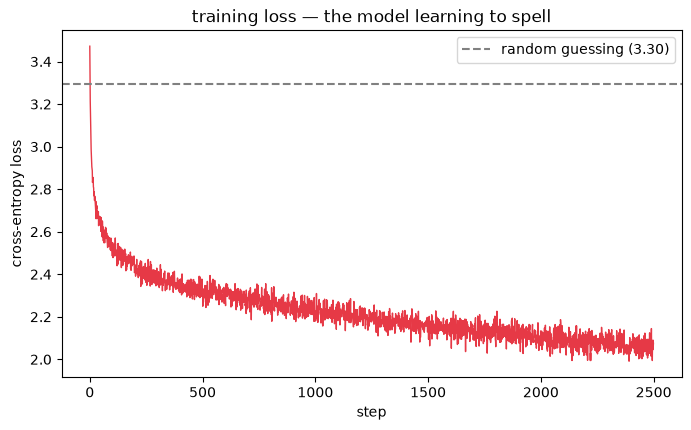

In [7]:
def get_batch(batch_size=64):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x, y

opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
steps = 2500
losses = []
t0 = time.time()
for step in range(steps):
    xb, yb = get_batch()
    _, loss = model(xb, yb)           # forward
    opt.zero_grad()                   # clear old gradients
    loss.backward()                   # backward (autograd)
    opt.step()                        # update weights
    losses.append(loss.item())
    if step in (0, steps // 3, 2 * steps // 3, steps - 1):
        print(f"step {step:4d}  loss {loss.item():.3f}   sample: "
              + generate(60, 0.8).replace("\n", " ").strip()[:60])
print(f"\ntrained in {time.time() - t0:.1f}s")

plt.plot(losses, color="#e63946", lw=1)
plt.axhline(np.log(vocab_size), color="gray", ls="--", label=f"random guessing ({np.log(vocab_size):.2f})")
plt.title("training loss — the model learning to spell")
plt.xlabel("step"); plt.ylabel("cross-entropy loss"); plt.legend()
plt.show()

## 7. 🎛️ Write new words — with a temperature knob

Now the trained model generates. Drag **temperature**:

- **low (0.2)** — cautious; common letter patterns, sometimes repetitive.
- **around 0.8** — the sweet spot; plausible, pronounceable invented words.
- **high (1.5+)** — reckless; the spelling falls apart into noise.

These are *new* words the model invented — not copied from the corpus.

In [8]:
def write(temperature, how_many):
    out = generate(how_many * 12, temperature)
    words = [w for w in out.split("\n") if len(w) >= 3][:how_many]
    print(f"temperature = {temperature:.2f}\n")
    print("   ".join(words))

interact(
    write,
    temperature=FloatSlider(value=0.8, min=0.1, max=2.0, step=0.05, description="temperature"),
    how_many=IntSlider(value=12, min=4, max=24, step=1, description="# words"),
);

interactive(children=(FloatSlider(value=0.8, description='temperature', max=2.0, min=0.1, step=0.05), IntSlide…

## 8. Peek inside: the learned, causal attention

Same picture as notebook 4's attention matrix — but now the weights are **learned** from
training, and the mask makes it **lower-triangular**: every character attends only to the
ones before it. Pick a head and a string and see where each character looks. Often a head
learns to focus on the previous character or two — enough to guess what letter comes next.

In [9]:
@torch.no_grad()
def show_attention(text_in, head):
    s = ("\n" + text_in)[:block_size]
    idx = torch.tensor([encode(s)])
    x = model.token_emb(idx) + model.pos_emb(torch.arange(len(s)))
    _, att = model.heads[head](x, return_att=True)
    A = att[0].numpy()
    labels = [c.replace("\n", "\\n") for c in s]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(A, cmap="viridis")
    ax.set_xticks(range(len(s))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(labels)
    ax.set_xlabel("attends TO"); ax.set_ylabel("current character")
    ax.set_title(f"head {head}: learned causal attention")
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.show()

interact(
    show_attention,
    text_in=Dropdown(options=["transformer", "attention", "language", "programming"],
                     value="transformer", description="string"),
    head=IntSlider(value=0, min=0, max=n_head - 1, step=1, description="head"),
);

interactive(children=(Dropdown(description='string', options=('transformer', 'attention', 'language', 'program…

## 9. This *is* a GPT — just tiny

You didn't build a toy *version* of a transformer. You built a transformer. The
architecture here is the same one behind frontier models; the differences are all
**scale** and **polish**:

| | your tiny GPT | a frontier LLM (rough) |
|---|---|---|
| parameters | ~30 thousand | hundreds of billions |
| layers (blocks) | 1 | dozens–100+ |
| attention heads | 3 | dozens per layer |
| token type | single characters | subword pieces |
| training data | ~22 KB of words | trillions of tokens of text/code |
| training time | ~15 seconds, 1 laptop CPU | months, thousands of GPUs |
| after pretraining | nothing | instruction tuning + RLHF for helpfulness/safety |

Scale that same next-token-prediction objective up far enough and the model stops just
spelling and starts completing code, translating, and reasoning. But the machine at the
core is the one you just trained.

## 10. Recap — you built the whole stack

- **Tokens → embeddings**, with **positional encoding** to add order.
- **Causal self-attention** so each position mixes in the relevant earlier ones without
  peeking ahead.
- A **per-position MLP**, with residuals + LayerNorm — a deep, trainable block.
- Trained by **next-character prediction** with cross-entropy, the same
  loss/gradient/`backward` loop from the very first notebooks.
- **Sampling with temperature** to generate new text.

That's the complete arc: from a single neuron (notebook 1) to a working language model
(this one).

**Where to go next**
- **Scale this up:** stack several blocks, widen `n_embd`, add more heads, train longer —
  watch the samples sharpen.
- **A real corpus:** swap the word list for a text file you like (song lyrics, code, a
  book) and see it pick up that style.
- **Karpathy's nanoGPT / "Let's build GPT"** — the same idea, written to scale, with a
  superb walkthrough.
- **Subword tokenization** (BPE) — how real models avoid character-by-character.
- **Fine-tuning** a pretrained model instead of training from scratch — the practical way
  most AI products are built today.